In [1]:
# !pip install --upgrade tensorflow

In [2]:
# !pip install --force-reinstall "numpy==1.26.4"

In [3]:
# !pip install fairchem
# !pip install fairchem-core

In [4]:
from fairchem.core.datasets import AseDBDataset

config_kwargs = {} # see tutorial on additional configuration
dataset_paths = [
      "/home/shtnp/Crystal-generator-using-SLICES/data/raw/sAlex/train/alex_go_aab_000.aselmdb"
]
dataset = AseDBDataset(config=dict(src=dataset_paths, **config_kwargs))

/home/shtnp/Crystal-generator-using-SLICES/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/shtnp/Crystal-generator-using-SLICES/.venv/lib/python3.10/site-packages/torchtnt/utils/version.py:12: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
2025-05-31 21:52:51.189281: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-31 21:52:51.202848: E external/local_xla/x

In [5]:
dataset[1000]

AtomicData(atomic_numbers=[8], batch=[8], cell=[1, 3, 3], cell_offsets=[0, 3], charge=[1], edge_index=[2, 0], energy=[1], fixed=[8], forces=[8, 3], natoms=[1], nedges=[1], pbc=[1, 3], pos=[8, 3], sid=[1], spin=[1], stress=[1, 3, 3], tags=[8])

In [6]:
from pymatgen.core import Structure, Lattice, Element
import numpy as np

def atomicdata_to_pmg_structure(atomic_data):
    cell = np.array(atomic_data.cell[0], copy=False)
    positions = np.array(atomic_data.pos, copy=False)
    atomic_numbers = np.array(atomic_data.atomic_numbers, copy=False)
    elements = [Element.from_Z(z).symbol for z in atomic_numbers]
    lattice = Lattice(cell)
    structure = Structure(
        lattice=lattice,
        species=elements,
        coords=positions,
        coords_are_cartesian=True
    )
    # try:
    #     structure.set_pbc(atomic_data.pbc[0])
    # except Exception:
    #     pass
    return structure


In [7]:
from fairchem.core.datasets import AseDBDataset

config_kwargs = {} # see tutorial on additional configuration
dataset_paths = [
      "/home/shtnp/Crystal-generator-using-SLICES/data/raw/sAlex/train"
]
dataset = AseDBDataset(config=dict(src=dataset_paths, **config_kwargs))
dataset[0]

AtomicData(atomic_numbers=[15], batch=[15], cell=[1, 3, 3], cell_offsets=[0, 3], charge=[1], edge_index=[2, 0], energy=[1], fixed=[15], forces=[15, 3], natoms=[1], nedges=[1], pbc=[1, 3], pos=[15, 3], sid=[1], spin=[1], stress=[1, 3, 3], tags=[15])

In [8]:
len(dataset)

10447765

In [9]:
dataset[0]

AtomicData(atomic_numbers=[15], batch=[15], cell=[1, 3, 3], cell_offsets=[0, 3], charge=[1], edge_index=[2, 0], energy=[1], fixed=[15], forces=[15, 3], natoms=[1], nedges=[1], pbc=[1, 3], pos=[15, 3], sid=[1], spin=[1], stress=[1, 3, 3], tags=[15])

In [10]:
dataset[0].energy

tensor([-38.8929])

In [11]:
# import pandas as pd
# from tqdm import tqdm

# size = 100_000

# records = [0] * size
# for i in tqdm(range(size)):
#     data = dataset[i]
#     # Example: Extracting common fields
#     record = {
#         "energy": data.energy.item() if hasattr(data.energy, 'item') else data.energy,
#         "natoms": data.natoms.item() if hasattr(data.natoms, 'item') else data.natoms,
#     }
#     # records.append(record)
#     records[i] = record

# df = pd.DataFrame(records)

In [12]:
# import pandas as pd
# from tqdm import tqdm
# from multiprocessing import Pool, cpu_count

# max_size = 400_000

# # ----
# # Put your dataset loading here
# # dataset = ...
# # ----

# def process_record(i):
#     data = dataset[i]
#     return {
#         "energy": data.energy.item() if hasattr(data.energy, 'item') else data.energy,
#         "natoms": data.natoms.item() if hasattr(data.natoms, 'item') else data.natoms,
#     }

# if __name__ == '__main__':
#     # Make dataset global so workers can access it
#     global dataset
#     # dataset = ...  # (uncomment this and put your dataset loading here)

#     with Pool(processes=2) as pool:
#         # tqdm progress bar for imap
#         records = list(tqdm(pool.imap(process_record, range(size)), total=size))

#     df = pd.DataFrame(records)

In [13]:
import sys, os
# sys.path.insert(0, os.path.abspath('..'))
sys.path.append('..')
# os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
# import warnings
# warnings.filterwarnings("ignore", message=".*You are casting an input of type complex64.*")

In [14]:
!cd .. && ./apply_patch.sh && cd -

/home/shtnp/Crystal-generator-using-SLICES/notebooks


In [15]:
from pymatgen.core import Structure
from pymatgen.analysis.structure_matcher import StructureMatcher
from pymatgen.symmetry.analyzer import SpacegroupAnalyzer

ltol=0.3
stol=0.5
angle_tol=5

matcher = StructureMatcher(
        ltol=ltol,  # lattice length tolerance (5%)
        stol=stol,   # site position tolerance (Å)
        angle_tol=angle_tol,  # angle tolerance (°)
        primitive_cell=True,
        scale=False
    )

def compare_structures(s1, s2, to_print=False):
    # s1 = original_structure
    # s2 = backend.SLICES2structure(slices_NdSiRu)[0]

    if s1.composition != s2.composition:
        return False

    # 2. Compare Lattice parameters manually (optional)
    tol = ltol  # 1% tolerance
    for a, b in zip(s1.lattice.abc, s2.lattice.abc):
        if abs(a-b)/max(a,b) > tol:
            if to_print: print(f"Lattice lengths differ by more than {int(ltol * 100)}%:", s1.lattice.abc, s2.lattice.abc)
            return False
    for α, β in zip(s1.lattice.angles, s2.lattice.angles):
        if abs(α-β) > angle_tol:  # 1° tolerance
            if to_print: print("Lattice angles differ by more than {angle_tol}°:", s1.lattice.angles, s2.lattice.angles)
            return False

    # 3. Compare Space Groups
    # spg1 = SpacegroupAnalyzer(s1).get_space_group_symbol()
    # spg2 = SpacegroupAnalyzer(s2).get_space_group_symbol()
    # if spg1 != spg2:
    #     print(f"Different space groups: {spg1} vs {spg2}")
    # else:
    #     print(f"Same space group: {spg1}")

    # 4. Fuzzy structure matching (accounts for cell reduction, slight distortions,
    #    ordering of sites, and atomic‐type permutations)

    # print(s1.composition)
    # print(s2.composition)

    # print(s2.lattice)
    # print(len(s2.sites))
    # print('---------------------')
    # print(s1.lattice)
    # print(len(s1.sites))

    # if any(not site.is_ordered for site in s2.sites):
    #     print("Partial occupancy detected.")

    # import numpy as np
    # if np.any(np.isnan([c for site in s2.sites for c in site.frac_coords])):
    #     print("NaN in coordinates!")

    

    # print(matcher.fit(s2, s2))
    # print('--------------')
    # print(matcher.fit(s1, s1))

    # return False

    are_fit = matcher.fit(s1.get_primitive_structure(), s2.get_primitive_structure())

    if to_print:
        if are_fit:
            print("Structures match (within tolerances) 🎉")
        else:
            print("Structures do not match.")
    return are_fit

In [16]:
# from pymatgen.core import Structure, Lattice, Element
# import numpy as np

# def atomicdata_to_pmg_structure(atomic_data):
#     cell = np.array(atomic_data.cell[0])
#     positions = np.array(atomic_data.pos)
#     atomic_numbers = np.array(atomic_data.atomic_numbers)
#     elements = [Element.from_Z(z).symbol for z in atomic_numbers]
#     lattice = Lattice(cell)
#     structure = Structure(
#         lattice=lattice,
#         species=elements,
#         coords=positions,
#         coords_are_cartesian=True
#     )
#     try:
#         structure.set_pbc(atomic_data.pbc[0])
#     except Exception:
#         pass
#     return structure

In [17]:
# from pymatgen.core import Structure, Lattice, Element
# import numpy as np

# def atomicdata_to_pmg_structure(atomic_data):
#     cell = atomic_data.cell[0]
#     positions = atomic_data.pos
#     atomic_numbers = atomic_data.atomic_numbers

#     # Fast lookup with cache
#     elements = [Element.from_Z(int(z)).symbol for z in atomic_numbers]

#     lattice = Lattice(cell)
#     structure = Structure(
#         lattice=lattice,
#         species=elements,
#         coords=positions,
#         coords_are_cartesian=True
#     )

#     # Set periodic boundary conditions if available
#     pbc = getattr(atomic_data, "pbc", None)
#     if pbc is not None and len(pbc) > 0:
#         try:
#             structure.set_pbc(pbc[0])
#         except Exception:
#             pass

#     return structure


In [18]:
# from tqdm import tqdm

# l = []

# for i in tqdm(dataset, smoothing=0.05):
#     l.append(atomicdata_to_pmg_structure(i))

In [19]:
from fairchem.core.datasets import AseDBDataset
from tqdm import tqdm
from src.slices_pipeline.encoder import *
from src.slices_pipeline.loader import *
from slices.core import SLICES
import traceback

folder = "/home/shtnp/Crystal-generator-using-SLICES/data/raw/sAlex/train"

def convert_to_slices(dataset_folder, save_file, max_amount=400_000):
    config_kwargs = {} # see tutorial on additional configuration
    dataset_paths = [
        dataset_folder
    ]
    dataset = AseDBDataset(config=dict(src=dataset_paths, **config_kwargs))

    backend = SLICES(relax_model="chgnt", steps=100)
    # backend = SLICES()

    overall_size = len(dataset)
    errors = 0
    no_match = 0
    no_fit = 0

    results = []

    with tqdm(total=max_amount, smoothing=0.05) as pbar:
        with open(save_file, "a") as f:
            for i, row in enumerate(dataset):
                try:
                    energy = row.energy.item() if hasattr(row.energy, 'item') else row.energy
                    natoms = row.natoms.item() if hasattr(row.natoms, 'item') else row.natoms
                    e_per_atom = energy / natoms
                    if e_per_atom < -0.5 and natoms >= 1 and natoms < 20:
                        no_match += 1
                        pbar.set_postfix(passed=f"{i}/{overall_size}", pass_rate=f"{len(results)/overall_size:.2%}", error=f"{errors}", no_match=f"{no_match}", no_fit=f"{no_fit}")
                        continue
                    original_structure = atomicdata_to_pmg_structure(row)
                    slices = backend.structure2SLICES(original_structure, strategy=3)
                    reconstructed_structure, final_energy_per_atom = backend.SLICES2structure(slices, strategy=3)
                    is_okay = compare_structures(original_structure, reconstructed_structure)
                    if not is_okay:
                        no_fit += 1
                        pbar.set_postfix(passed=f"{i}/{overall_size}", pass_rate=f"{len(results)/overall_size:.2%}", error=f"{errors}", no_match=f"{no_match}", no_fit=f"{no_fit}")
                        continue
                    f.write(f"{slices};{natoms};{e_per_atom}\n")
                    f.flush()
                    results.append({"slices": slices, "natoms": natoms, "e_per_atoms": e_per_atom})
                    pbar.update(1)
                    pbar.set_postfix(passed=f"{i}/{overall_size}", pass_rate=f"{len(results)/overall_size:.2%}", error=f"{errors}", no_match=f"{no_match}", no_fit=f"{no_fit}")
                    if len(results) >= max_amount:
                        print(f"{max_amount} samples found!")
                        break
                except Exception as e:
                    errors += 1
                    # print("Error:", e)
                    # traceback.print_exc()

    print("Saving samples...")

    df = pd.DataFrame(data)
    try:
        # Save as CSV
        df.to_csv(save_file, index=False)
    except Exception as e:
        print(e)
    finally:
        return df

Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead


Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead


In [20]:
# from src.slices_pipeline.encoder import *
# from src.slices_pipeline.loader import *
# from slices.core import SLICES
# from pymatgen.core.structure import Structure
# from multiprocessing import Process, Queue
# from pymatgen.io.cif import CifParser
# from io import StringIO
# from tqdm import tqdm
# from queue import Empty
# import time
# import os
# import gc
# import psutil

# import logging
# import tensorflow as tf

# ram_threshold = 50

# # Suppress TensorFlow logger warnings
# # tf.get_logger().setLevel(logging.ERROR)

# def get_mp20_split(split):
#     if split is None:
#         df = pd.concat([read_split_df("train"), read_split_df("test"), read_split_df("val")])
#         return df, "full"
#     else:
#         df = read_split_df(split)
#         return df, split

# def job(rows, queue, worker_id, free_queue):
#     # Suppress TensorFlow logger warnings
#     # tf.get_logger().setLevel(logging.ERROR)

#     # sys.stdout = open(os.devnull, 'w')
#     # sys.stderr = open(os.devnull, 'w')
#     # Setup: e.g., load a model, establish a connection, etc.
#     # print(f"Worker {worker_id} setup complete")

#     def get_relax(queue, slices):
#         queue.put(backend.SLICES2structure(slices_NdSiRu))

#     backend = SLICES(relax_model="chgnet", steps=100)
#     # backend = SLICES()

#     gc_each = 10
#     i = 0

#     for idx, row in rows.iterrows():
#         # Simulate processing (replace with your logic)
#         # result = row['value'] ** 2
#         # print(f"Processing: {row.material_id}")

#         start_time = time.time()
#         material_id = row.material_id
#         try:
#             # original_structure = Structure.from_str(cif, fmt="cif", primitive=True)
#             cif = row.cif
#             original_structure = CifParser(StringIO(cif)).parse_structures()[0]
#             # print(i, df.iloc[i].material_id)
#             slices_NdSiRu = backend.structure2SLICES(original_structure)
#             reconstructed_structure, final_energy_per_atom = backend.SLICES2structure(slices_NdSiRu)
#             is_okay = compare_structures(original_structure, reconstructed_structure)
#             if not is_okay:
#                 # print(7)
#                 # reconstructed_structure, final_energy_per_atom = backend.relax(reconstructed_structure)
#                 reconstructed_structure, final_energy_per_atom = run_with_memory_limit(get_relax, slices=slices_NdSiRu)
#                 # print(8)
#                 is_okay = compare_structures(original_structure, reconstructed_structure)
#             # if is_okay: correct += 1
#             end_time = time.time()
#             # data.append(f"{' ' if is_okay else 'x'} {i}: {df.iloc[i]['material_id']} --- {end_time - start_time}")
#             queue.put((worker_id, f"{' ' if is_okay else 'x'} {idx}: {material_id} --- {end_time - start_time}"))
#         except Exception as e:
#             # print(e)
#             # error += 1
#             end_time = time.time()
#             # data.append(f"E {i}: {df.iloc[i]['material_id']} --- {end_time - start_time}")
#             queue.put((worker_id, f"E {idx}: {material_id} --- {end_time - start_time}"))
#         finally:
#             i += 1
#             # if i % gc_each == 0:
#             #     gc.collect()
#             # # TODO Test
#             # if i % (gc_each * 2) == 0:
#             #     backend = SLICES()
#             # print(mem.percent, mem.available / mem.total, mem.available / mem.total < (1 - ram_threshold), 1 - ram_threshold)
#             # if mem.available / mem.total < (1 - ram_threshold):
#             # print(mem.percent, ram_threshold)
#             if psutil.virtual_memory().percent > ram_threshold:
#                 # print(11111)
#                 free_queue.put((worker_id, rows[i:]))
#                 return

#         # queue.put((worker_id, idx))  # Report subtask done

#     queue.put((worker_id, None))  # Signal this worker is done

# def run_split_parallel(df_func, start_from=0, append_previous_result=True, jobs=2, lost_file=None):
#     df, split = df_func()
#     correct = 0
#     overall = 0
#     error = 0
#     initial_size = df.shape[0]
#     file_to_save = f"results-{split}.txt" if lost_file is None else f"results-{lost_file}"
#     to_gc = 200
#     if lost_file is not None:
#         with open(lost_file, 'r', encoding='utf-8') as f:
#             lines = f.readlines()
#             if len(lines) > 0:
#                 if not lines[-1]:
#                     lines = lines[:-1]
#                 lines = [line[:-1] for line in lines]
#                 num_lines = len(lines)
#                 initial_size = num_lines
#                 df = df[df['material_id'].isin(lines)]
#     if (append_previous_result or start_from > 0) and os.path.exists(file_to_save):
#         with open(file_to_save, 'r', encoding='utf-8') as f:
#             lines = f.readlines()
#             if len(lines) > 0:
#                 if not lines[-1]:
#                     lines = lines[:-1]
#                 num_lines = len(lines)
#                 correct = sum(1 for l in lines if l[0] == ' ')
#                 overall = num_lines
#                 error = sum(1 for l in lines if l[0] == 'E')
#                 start_from = num_lines
#                 to_remove_ids = get_materail_ids(file_to_save)
#                 df = df[~df['material_id'].isin(to_remove_ids)]
#     data = []
#     # backend = SLICES(relax_model="chgnet", steps=100)
#     # backend = SLICES()
    
#     batch_size = df.shape[0] // jobs
#     queue = Queue()

#     freed_processes_queue = Queue()

#     processes = []
#     for i in range(jobs):
#         start = i * batch_size
#         end = None if i == jobs-1 else (i+1) * batch_size
#         batch = df.iloc[start:end]
#         p = Process(target=job, args=(batch, queue, i, freed_processes_queue))
#         processes.append(p)
#         p.start()

#     i = start_from
#     finished_workers = 0
#     with tqdm(total=initial_size, initial=start_from, smoothing=0.05) as pbar:
#         while finished_workers < jobs:
#             worker_id, string = queue.get()
#             if string is not None:
#                 if string[0] == 'E':
#                     error += 1
#                 elif string[0] == ' ':
#                     correct += 1

#                 overall += 1
#                 data.append(string)

#                 pbar.set_postfix(correct=f"{correct}/{overall}", accuracy=f"{correct/overall:.2%}", error=f"{error}")
#                 pbar.update(1)
#                 i += 1

#                 if i % 10 == 9:
#                     with open(file_to_save, "a", encoding="utf-8") as f:
#                         f.writelines(line + "\n" for line in data)
#                     data = []

#                 if i % to_gc == 0:
#                     gc.collect()

#                 try:
#                     freed_process, left_job = freed_processes_queue.get_nowait()
#                     processes[freed_process] = Process(target=job, args=(left_job, queue, freed_process, freed_processes_queue))
#                     processes[freed_process].start()
#                 except Empty:
#                     pass
#             else:
#                 finished_workers += 1
#         with open(file_to_save, "a", encoding="utf-8") as f:
#             f.writelines(line + "\n" for line in data)
#     for p in processes:
#         p.join()



#     # with tqdm(total=df.shape[0], initial=start_from, smoothing=0.9) as pbar:
#     #     for i, cif in enumerate(df.cif.iloc[start_from:], start=start_from):
#     #         start_time = time.time()
#     #         try:
#     #             # original_structure = Structure.from_str(cif, fmt="cif", primitive=True)
#     #             original_structure = CifParser(StringIO(cif)).parse_structures()[0]
#     #             # print(i, df.iloc[i].material_id)
#     #             slices_NdSiRu = backend.structure2SLICES(original_structure)
#     #             reconstructed_structure, final_energy_per_atom = backend.SLICES2structure(slices_NdSiRu)
#     #             is_okay = compare_structures(original_structure, reconstructed_structure)
#     #             if is_okay: correct += 1
#     #             end_time = time.time()
#     #             data.append(f"{' ' if is_okay else 'x'} {i}: {df.iloc[i]['material_id']} --- {end_time - start_time}")
#     #         except Exception:
#     #             error += 1
#     #             end_time = time.time()
#     #             data.append(f"E {i}: {df.iloc[i]['material_id']} --- {end_time - start_time}")
#     #         finally:
#     #             overall += 1
#     #             pbar.set_postfix(correct=f"{correct}/{overall}", accuracy=f"{correct/overall:.2%}", error=f"{error}")
#     #             pbar.update(1)
#     #             if i % 10 == 9:
#     #                 with open(file_to_save, "a", encoding="utf-8") as f:
#     #                     f.writelines(line + "\n" for line in data)
#     #                 data = []
#     # with open(file_to_save, "a", encoding="utf-8") as f:
#     #     f.writelines(line + "\n" for line in data)

In [21]:
def filtered_range(start, stop, drop_list):
    drop_set = set(drop_list)
    for x in range(start, stop):
        if x not in drop_set:
            yield x

def chunked(iterable, chunk_size):
    chunk = []
    for item in iterable:
        chunk.append(item)
        if len(chunk) == chunk_size:
            yield chunk
            chunk = []
    if chunk:
        yield chunk

In [22]:
from fairchem.core.datasets import AseDBDataset
from concurrent.futures import ProcessPoolExecutor
from concurrent.futures import ThreadPoolExecutor   
from tqdm import tqdm
from src.slices_pipeline.encoder import *
from src.slices_pipeline.loader import *
from slices.core import SLICES
import traceback
from multiprocessing import Queue, Process

folder = "/home/shtnp/Crystal-generator-using-SLICES/data/raw/sAlex/train"

def process_rows_job(dataset_folder, receiver_range, done_queue, done_processes_queue):
    sys.stdout = open(os.devnull, 'w')
    sys.stderr = open(os.devnull, 'w')

    config_kwargs = {} # see tutorial on additional configuration
    dataset_paths = [
        dataset_folder
    ]
    df = AseDBDataset(config=dict(src=dataset_paths, **config_kwargs))

    backend = SLICES(relax_model="chgnt", steps=100)

    for i in receiver_range:
        row = df[i]
        try:
            energy = row.energy.item() if hasattr(row.energy, 'item') else row.energy
            natoms = row.natoms.item() if hasattr(row.natoms, 'item') else row.natoms
            e_per_atom = energy / natoms
            if e_per_atom >= -0.5 or natoms >= 20:
                done_queue.put((0, None, i))
                continue
            # if e_per_atom < -0.5 and natoms >= 1 and natoms < 20:
            #     done_queue.put((0, None, i))
            #     # no_match += 1
            #     # pbar.set_postfix(passed=f"{i}/{overall_size}", pass_rate=f"{len(results)/overall_size:.2%}", error=f"{errors}", no_match=f"{no_match}", no_fit=f"{no_fit}")
            #     continue
            original_structure = atomicdata_to_pmg_structure(row)
            slices = backend.structure2SLICES(original_structure, strategy=3)
            reconstructed_structure, final_energy_per_atom = backend.SLICES2structure(slices, strategy=3)
            is_okay = compare_structures(original_structure, reconstructed_structure)
            if not is_okay:
                done_queue.put((1, None, i))
                # no_fit += 1
                # pbar.set_postfix(passed=f"{i}/{overall_size}", pass_rate=f"{len(results)/overall_size:.2%}", error=f"{errors}", no_match=f"{no_match}", no_fit=f"{no_fit}")
                continue
            # f.write(f"{slices};{natoms};{e_per_atom}\n")
            # f.flush()
            done_queue.put((2, f"{i};{slices};{natoms};{e_per_atom}", i))
            # results.append({"slices": slices, "natoms": natoms, "e_per_atoms": e_per_atom})
            # pbar.update(1)
            # pbar.set_postfix(passed=f"{i}/{overall_size}", pass_rate=f"{len(results)/overall_size:.2%}", error=f"{errors}", no_match=f"{no_match}", no_fit=f"{no_fit}")
            # if len(results) >= max_amount:
            #     print(f"{max_amount} samples found!")
            #     break
        except Exception as e:
            # errors += 1
            done_queue.put((3, None, i))
            # print("Error:", e)
            # traceback.print_exc()

def convert_to_slices_parallel(dataset_folder, save_file, max_amount=400_000, jobs=4):
    # backend = SLICES(relax_model="chgnt", steps=100)
    # backend = SLICES()

    config_kwargs = {} # see tutorial on additional configuration
    dataset_paths = [
        dataset_folder
    ]

    df = AseDBDataset(config=dict(src=dataset_paths, **config_kwargs))

    batch_size = len(df) // jobs
    if os.path.exists(f"save-idx-{save_file}"):
        with open(f"save-idx-{save_file}", "r") as f:
            drop = [int(line.strip()) for line in f if line.strip()]
            filtered = filtered_range(0, len(df), drop)
            batch_size = (len(df) - len(drop)) // jobs
            batches = list(chunked(filtered, batch_size))
    else:
        drop = []
        batches = [range(i * batch_size, (i + 1) * batch_size) for i in range(jobs - 1)]
        batches.append(range((jobs - 1) * batch_size, len(dataset)))

    overall_size = len(df)
    errors = 0
    no_match = 0
    no_fit = 0

    results = []

    result_queue = Queue()

    done_processes_queue = Queue()

    overall_size = len(df)
    errors = 0
    no_match = 0
    no_fit = 0
    passed_results = len(drop)

    # processes = []
    for i in range(jobs):
        p = Process(target=process_rows_job, args=(dataset_folder, batches[i], result_queue, done_processes_queue))
        # processes.append(p)
        p.start()

    if os.path.exists(save_file):
        with open(save_file, "r") as f:
            i = len([line for line in f if line.strip()])
    else:
        i = 0

    # try:
    # with ThreadPoolExecutor(max_workers=jobs) as executor:
    with ProcessPoolExecutor(max_workers=jobs) as executor:
        # for i in executor.map(process_rows_job, [dataset_folder] * jobs, batches, [result_queue] * jobs, [done_processes_queue] * jobs):
        #     print(i)
        with tqdm(total=max_amount, smoothing=0.05, initial=i) as pbar:
        # with tqdm(total=overall_size, smoothing=0.05, initial=passed_results) as pbar:
            with open(save_file, "a") as f:
                with open(f"save-idx-{save_file}", "a") as f_idx:
                    while done_processes_queue.qsize() < jobs:
                        status, results, idx = result_queue.get(block=True, timeout=None)
                        if results is not None:
                            i += 1
                            pbar.update(1)
                            f.write(results + "\n")
                            f.flush()
                        elif status == 0:
                            no_match += 1
                        elif status == 1:
                            no_fit += 1
                        else:
                            errors += 1
                        # pbar.update(1)
                        passed_results += 1
                        # pbar.set_postfix(passed=f"{i}/{max_amount}", pass_rate=f"{i/max_amount:.2%}", error=f"{errors}", no_match=f"{no_match}", no_fit=f"{no_fit}")
                        pbar.set_postfix(passed=f"{passed_results}/{overall_size}", pass_rate=f"{passed_results/overall_size:.2%}", error=f"{errors}", no_match=f"{no_match}", no_fit=f"{no_fit}")
                        f_idx.write(str(idx) + "\n")
                        f_idx.flush()
    # except Exception as e:
    #     print(e)

In [ ]:
convert_to_slices_parallel("/home/shtnp/Crystal-generator-using-SLICES/data/raw/sAlex/train", "salex-slices.csv", jobs=48)

  3%|▎         | 10272/400000 [00:15<21:31:51,  5.03it/s, error=22, no_fit=32, no_match=27, pass_rate=4.30%, passed=449116/10447765]ERROR:root:Could not obtain the lattice basis from the cycle vectors!
ERROR:root:Could not obtain the lattice basis from the cycle vectors!
  3%|▎         | 10383/400000 [00:33<16:58:23,  6.38it/s, error=51, no_fit=81, no_match=35, pass_rate=4.30%, passed=449313/10447765]ERROR:root:Could not obtain the lattice basis from the cycle vectors!
ERROR:root:Could not obtain the lattice basis from the cycle vectors!
  3%|▎         | 10785/400000 [01:32<14:13:27,  7.60it/s, error=158, no_fit=242, no_match=185, pass_rate=4.31%, passed=450133/10447765]ERROR:root:Could not obtain the lattice basis from the cycle vectors!
ERROR:root:Could not obtain the lattice basis from the cycle vectors!
  3%|▎         | 10800/400000 [01:35<16:36:44,  6.51it/s, error=167, no_fit=253, no_match=199, pass_rate=4.31%, passed=450182/10447765]ERROR:root:Could not obtain the lattice basis 

In [ ]:
from pymatgen.core.structure import Structure
from slices.core import SLICES
from pymatgen.io.cif import CifParser

def test(cif):
    backend = SLICES(relax_model="we")
    original_structure = CifParser(cif).parse_structures()[0]
    slices_NdSiRu = backend.structure2SLICES(original_structure)
    reconstructed_structure, final_energy_per_atom = backend.SLICES2structure(slices_NdSiRu)
    is_okay = compare_structures(original_structure, reconstructed_structure)
    return is_okay

In [ ]:
test("/home/shtnp/Crystal-generator-using-SLICES/notebooks/C_mp-66_computed.cif")

/tmp/ipykernel_121256/4212790295.py:7: UserWarning: The default value of primitive was changed from True to False in https://github.com/materialsproject/pymatgen/pull/3419. CifParser now returns the cell in the CIF file as is. If you want the primitive cell, please set primitive=True explicitly.
  original_structure = CifParser(cif).parse_structures()[0]


True

In [ ]:
df["e_per_atom"] = df["energy"] / df["natoms"]

print("Min e_per_atom:", df["e_per_atom"].min())  
print("Max e_per_atom:", df["e_per_atom"].max())
print("Median e_per_atom:", df["e_per_atom"].median())
print("Mean e_per_atom:", df["e_per_atom"].mean())

NameError: name 'df' is not defined

In [ ]:
for i in dataset[0]:
    print(i[0], i[1])

atomic_numbers tensor([47, 47, 47, 47, 47, 47, 47, 47, 47, 47, 47, 47, 47, 48, 48])
batch tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
cell tensor([[[ 5.0879e+00,  2.6995e-01,  6.9364e-03],
         [-3.0440e-01,  7.2033e+00, -6.6108e-01],
         [-7.8136e-01, -4.2141e+00,  7.8313e+00]]])
cell_offsets tensor([], size=(0, 3))
charge tensor([0])
edge_index tensor([], size=(2, 0), dtype=torch.int64)
energy tensor([-38.8929])
fixed tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
forces tensor([[ 7.6270e-04,  1.3638e-03,  1.5042e-03],
        [-7.6270e-04, -1.3638e-03, -1.5042e-03],
        [-0.0000e+00, -0.0000e+00, -0.0000e+00],
        [-3.4816e-04, -9.9190e-05, -1.1666e-03],
        [ 3.4816e-04,  9.9190e-05,  1.1666e-03],
        [ 8.4745e-04, -8.5680e-05, -5.7949e-04],
        [-8.4745e-04,  8.5680e-05,  5.7949e-04],
        [-1.2281e-03, -1.0627e-03, -9.8179e-04],
        [ 1.2281e-03,  1.0627e-03,  9.8179e-04],
        [-2.6494e-04, -1.1562e-04, -5.4013e-04],
      

In [2]:
import pandas as pd

In [ ]:
slices = pd.read_csv("salex-slices.csv", delimiter=";", names=["orig_id", "slices", "natoms", "e_per_atom"], header=None)
slices = slices[~slices.isna().any(axis=1)]
slices = slices[(slices.natoms < 20) & (slices.e_per_atom < -0.5)]
slices = slices.drop_duplicates(subset=['orig_id'], keep='first')
slices

,orig_id,slices,natoms,e_per_atom
0,1306120,La La La La In In Sn Sn Sn Sn Rh Rh Rh Rh Rh R...,20.0,-6.272686
1,2611940,Ga Ga Ga Ga Ni Ni Ni Ni Pt Pt Pt Pt Pt Pt Pt P...,20.0,-5.614831
2,2611947,Cd Cd Cd Cd Cd Cd Cd Cd Cd Cd Cd Cd Ag Ag Au A...,20.0,-1.878980
3,1306121,La La La La In In Sn Sn Sn Sn Rh Rh Rh Rh Rh R...,20.0,-6.264138
4,122,Ag Ag Ag Ag Ag Ag Ag Ag Ag Ag Ag Ag Te Te Te T...,20.0,-2.999581
...,...,...,...,...
451698,7528197,Ni Ca Ca Cu 0 2 o o o 0 2 o + o 0 2 + o o 0 2 ...,4.0,-3.497263
451699,6471440,Pb Hf Hf Se 0 1 o o o 0 1 + o o 0 1 o + o 0 2 ...,4.0,-7.105467
451700,6261193,F F F F Rb Rb V 0 6 o o + 0 4 o o o 0 5 o o o ...,7.0,-5.105946
451701,1323248,Sr Sr Sr Zn Zn In Au Au Au Au Au Au 0 11 - o o...,12.0,-2.936802


In [19]:
slices[slices.orig_id.duplicated()]

,orig_id,slices,natoms,e_per_atom
4345,2607147,Ti Ti Ti Ti Ti Ti Mn Mn Pd Pd Pd Pd Pd Pd Pd P...,20.0,-6.747089


In [20]:
slices[slices.orig_id == 2607147]

,orig_id,slices,natoms,e_per_atom
2519,2607147,Ti Ti Ti Ti Ti Ti Mn Mn Pd Pd Pd Pd Pd Pd Pd P...,20.0,-6.747089
4345,2607147,Ti Ti Ti Ti Ti Ti Mn Mn Pd Pd Pd Pd Pd Pd Pd P...,20.0,-6.747089


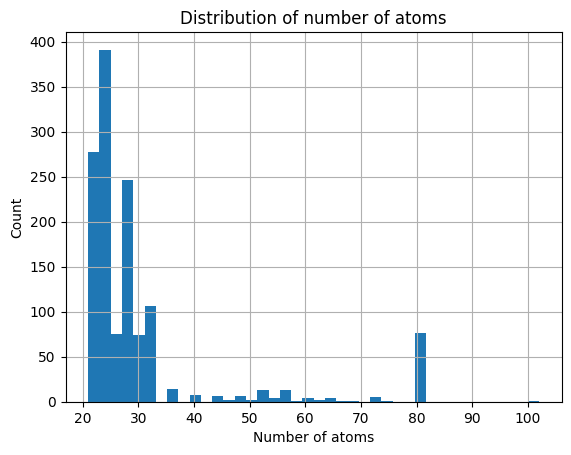

In [29]:
import matplotlib.pyplot as plt

slices[slices.natoms > 20]['natoms'].hist(bins=40)
plt.xlabel('Number of atoms')
plt.ylabel('Count')
plt.title('Distribution of number of atoms')
plt.show()

In [32]:
slices[(slices.natoms < 20) & (slices.e_per_atom < -0.5)].shape[0]

447303